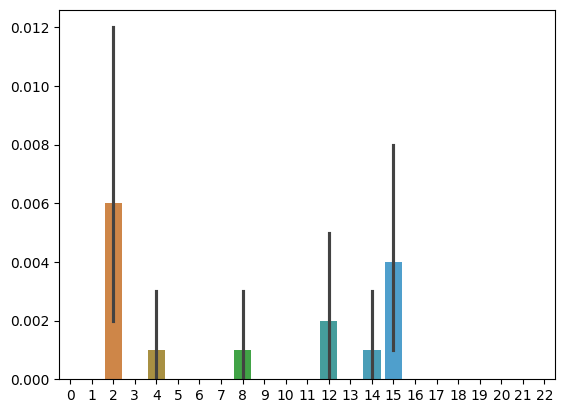

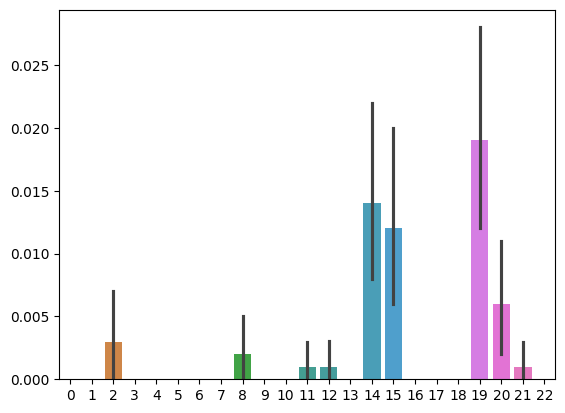

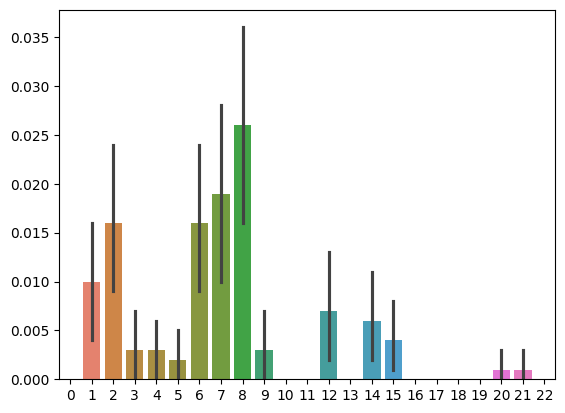

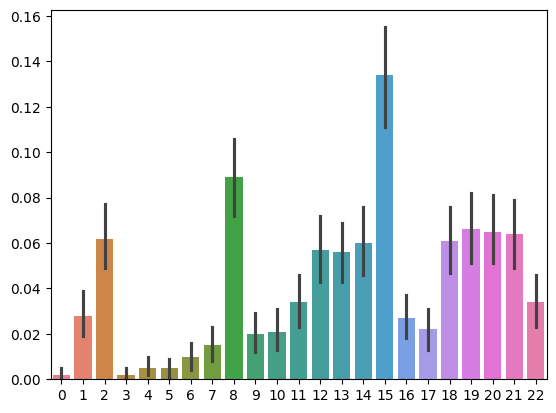

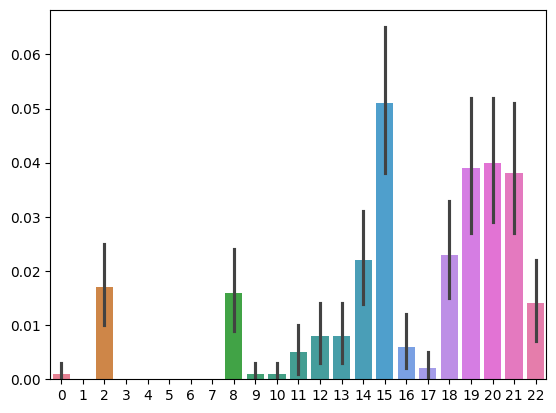

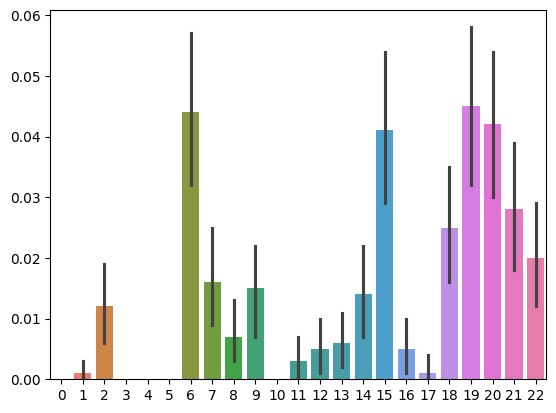

In [ ]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

result_names = [
    # "results_2025-07-27_14-32-25", 
    # "results_2025-07-27_14-38-35", 
    # "results_2025-07-27_15-25-43", 
    # "results_2025-07-27_15-32-29", 
    "results_2025-07-27_16-02-36", # corrupted token 3, mlp
    "results_2025-07-27_16-24-15", # corrupted token 3, att
    "results_2025-07-27_16-30-40", # corrupted token 2, att
    "results_2025-07-27_16-35-47", # corrupted token 2, att
]

for filename in result_names:
    df = pd.read_csv(f"{filename}.csv")

    df['restored'] = df['restored'].apply(ast.literal_eval)
    df_expanded = df['restored'].apply(pd.Series)
    df_final = pd.concat([df.drop('restored', axis=1), df_expanded], axis=1)

    for i in range(23):
        df_final[i] = df_final["clean"] != df_final[i]

    df_preproc = df_final.drop('run_number', axis=1)
    df_preproc = df_preproc.drop('clean', axis=1)
    df_preproc = df_preproc.drop('corrupted', axis=1)

    sns.barplot(data=df_preproc)
    plt.show()
